--- Step 1: Preprocessing ---


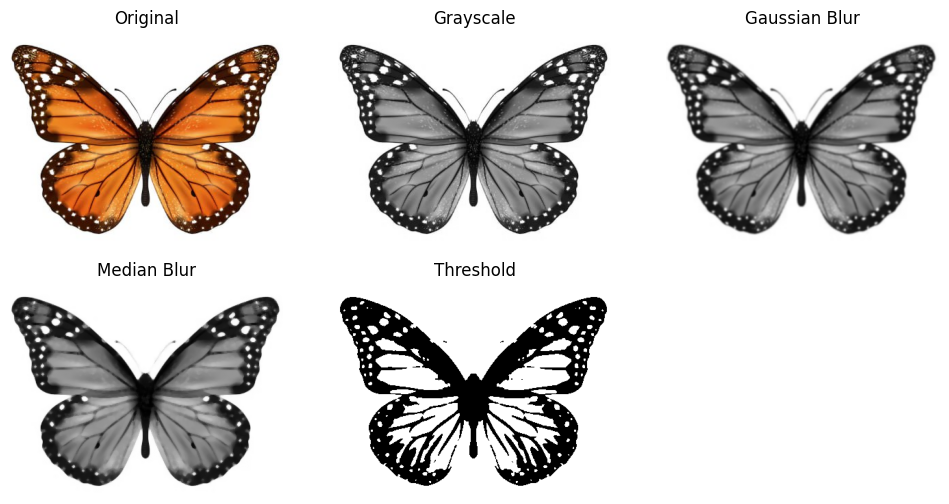

--- Step 2: Feature Extraction ---
HOG Feature Vector Size: (3651480,)


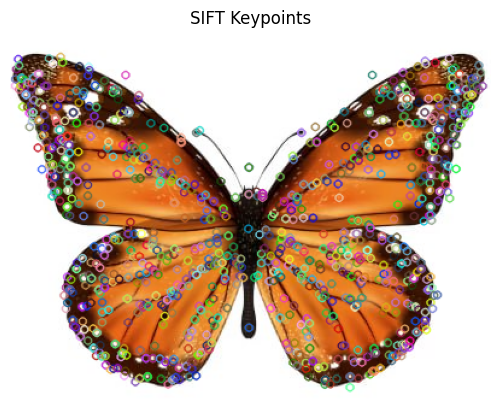

--- Step 3: Feature Matching ---


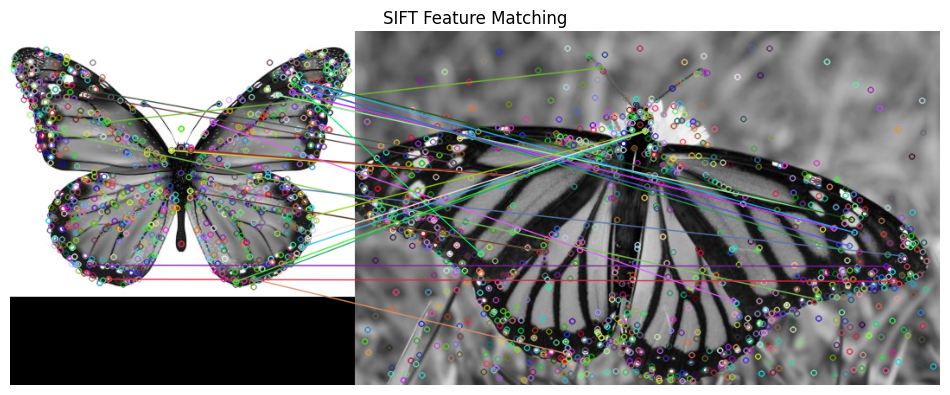

Total Matches: 1008
Good Matches: 30

Interpretation:
- More good matches → images are similar
- Fewer matches → scene change or different objects


In [16]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Image paths
img1_path = "/content/drive/MyDrive/img1.jpg"
img2_path = "/content/drive/MyDrive/img2.jpg"

# -----------------------------
# 1. Preprocessing (on img1)
# -----------------------------

def preprocess_image(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Noise removal
    gaussian = cv2.GaussianBlur(gray, (5, 5), 0)
    median = cv2.medianBlur(gray, 5)

    # Thresholding
    _, thresh = cv2.threshold(gaussian, 127, 255, cv2.THRESH_BINARY)

    # Display results
    titles = ['Original', 'Grayscale', 'Gaussian Blur', 'Median Blur', 'Threshold']
    images = [img, gray, gaussian, median, thresh]

    plt.figure(figsize=(12,6))
    for i in range(5):
        plt.subplot(2,3,i+1)
        if i == 0:
            plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

    return gray

# -----------------------------
# 2. Feature Extraction (HOG + SIFT)
# -----------------------------

def extract_features(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # HOG
    hog = cv2.HOGDescriptor()
    hog_features = hog.compute(gray)
    print("HOG Feature Vector Size:", hog_features.shape)

    # SIFT
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray, None)

    sift_img = cv2.drawKeypoints(img, keypoints, None)

    plt.imshow(cv2.cvtColor(sift_img, cv2.COLOR_BGR2RGB))
    plt.title("SIFT Keypoints")
    plt.axis('off')
    plt.show()

    return keypoints, descriptors

# -----------------------------
# 3. Feature Matching (img1 vs img2)
# -----------------------------

def feature_matching(img1_path, img2_path):
    img1 = cv2.imread(img1_path, 0)
    img2 = cv2.imread(img2_path, 0)

    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    # BF Matcher
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    # Ratio test
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    matched_img = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None)

    plt.figure(figsize=(12,6))
    plt.imshow(matched_img, cmap='gray')
    plt.title("SIFT Feature Matching")
    plt.axis('off')
    plt.show()

    print("Total Matches:", len(matches))
    print("Good Matches:", len(good_matches))

    print("\nInterpretation:")
    print("- More good matches → images are similar")
    print("- Fewer matches → scene change or different objects")

# -----------------------------
# RUN ALL STEPS
# -----------------------------

print("--- Step 1: Preprocessing ---")
preprocess_image(img1_path)

print("--- Step 2: Feature Extraction ---")
extract_features(img1_path)

print("--- Step 3: Feature Matching ---")
feature_matching(img1_path, img2_path)
